> **Branch:** `feature/stage8-explainability`  
> **Author:** Adithyan  
> ⚠️ **Before running:** Make sure you have already run `stage00_dataset_generator.ipynb` in the same Colab session so that `/content/dataset` and all shared variables are available.


---
# STAGE 8 — Model Interpretation & Explainability
**Author: Adithyan**  
**Branch: feature/stage8-explainability**

---

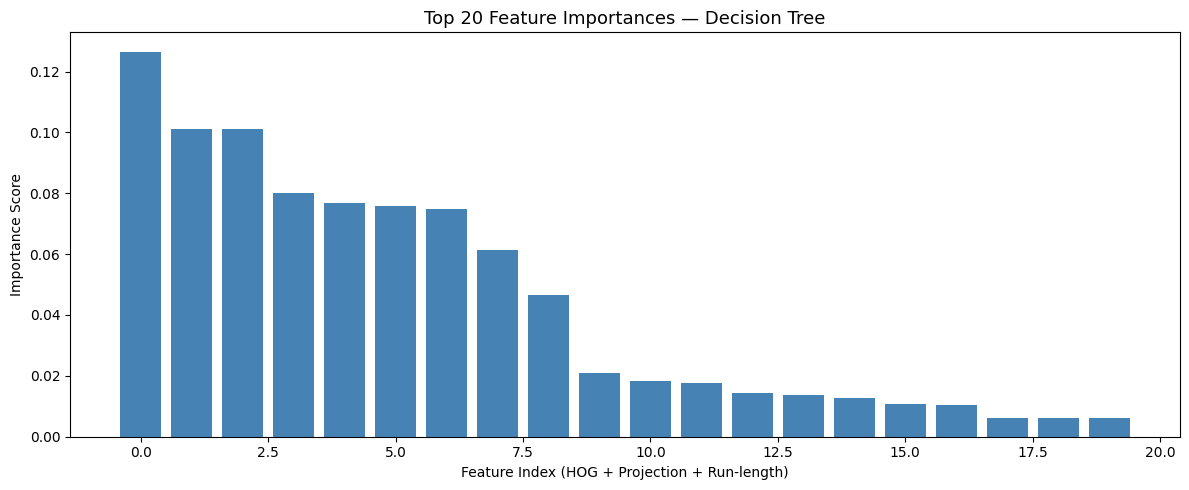

Top feature index: 1775 (importance=0.1265)


In [35]:
# ============================================================
# STAGE 8 — MODEL INTERPRETATION & EXPLAINABILITY
# Author: Adithyan
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ── 8.1 Decision Tree Feature Importances ─────────────────
importances = dt_model.feature_importances_
top_n = 20
top_indices = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(12, 5))
plt.bar(range(top_n), importances[top_indices], color='steelblue')
plt.title(f'Top {top_n} Feature Importances — Decision Tree', fontsize=13)
plt.xlabel('Feature Index (HOG + Projection + Run-length)')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150)
plt.show()
print(f"Top feature index: {top_indices[0]} (importance={importances[top_indices[0]]:.4f})")

Total misclassified: 5 / 700


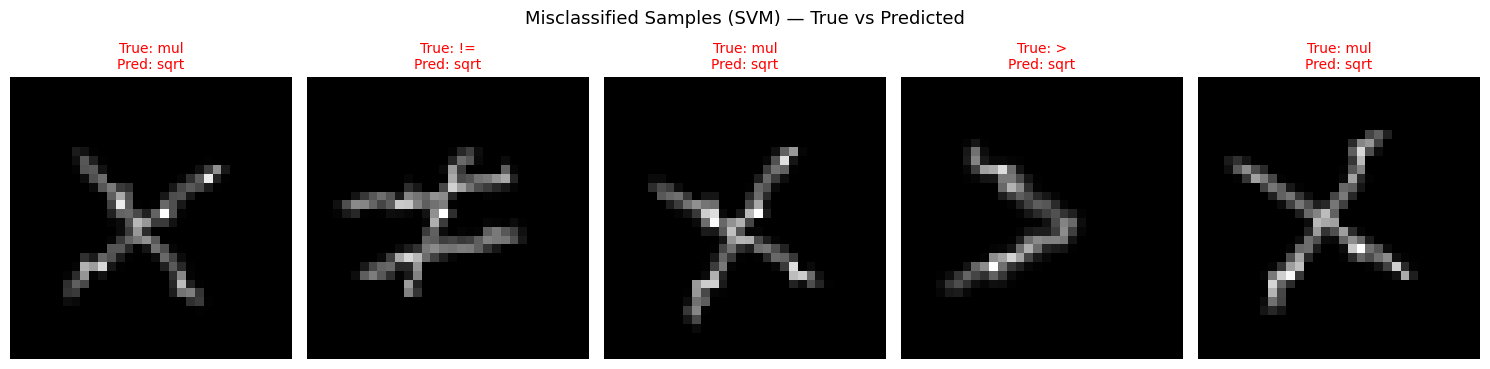

In [37]:
# ── 8.2 Misclassified Samples Visualisation ───────────────
best_model = svm_model
y_pred_best = best_model.predict(X_test)

misclassified_idx = np.where(y_pred_best != y_test)[0]
print("Total misclassified: " + str(len(misclassified_idx)) + " / " + str(len(y_test)))

show_n = min(5, len(misclassified_idx))

if show_n == 0:
    print("No misclassified samples — SVM is perfect on test set!")
else:
    fig, axes = plt.subplots(1, show_n, figsize=(show_n*3, 4))
    if show_n == 1:
        axes = [axes]
    fig.suptitle('Misclassified Samples (SVM) — True vs Predicted', fontsize=13)

    # Get original pixel data for test samples
    # X_test indices correspond to rows in X_scaled
    # We need the original flattened images from X
    from sklearn.model_selection import train_test_split
    _, X_test_orig, _, _ = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    symbol_names = list(class_mapping.values())

    for ax, idx in zip(axes, misclassified_idx[:show_n]):
        img = X_test_orig[idx].reshape(32, 32)
        true_sym = symbol_names[y_test[idx]]
        pred_sym = symbol_names[y_pred_best[idx]]
        ax.imshow(img, cmap='gray')
        ax.set_title('True: ' + str(true_sym) + '\nPred: ' + str(pred_sym),
                     color='red', fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('misclassified_samples.png', dpi=150)
    plt.show()

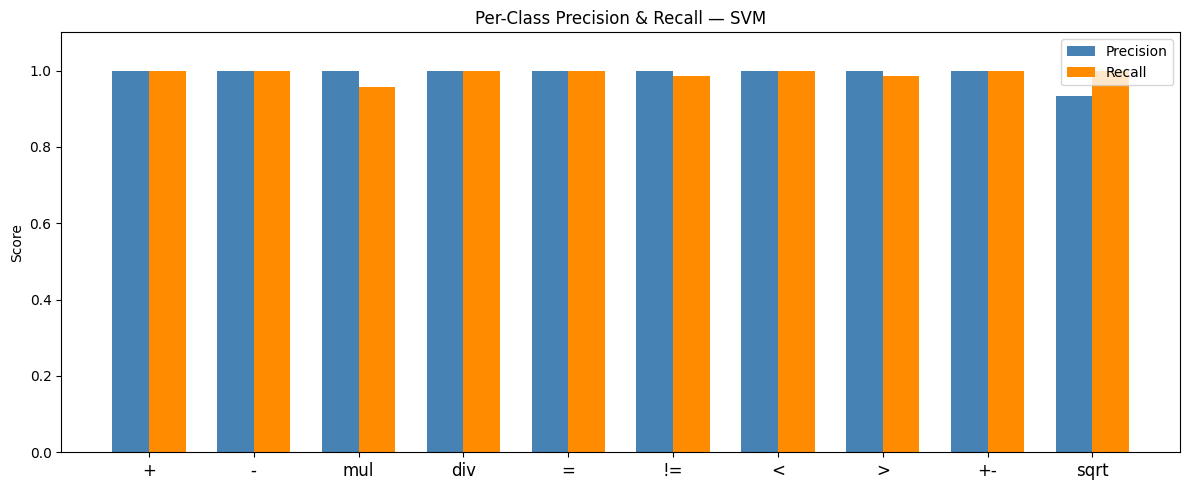

Stage 8 Complete ✅


In [38]:
# ── 8.3 Per-Class Precision-Recall Bar Chart ──────────────
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test, y_pred_best,
    target_names=symbol_names,
    output_dict=True
)
df_report = pd.DataFrame(report).T.iloc[:-3]  # remove avg rows

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(symbol_names))
w = 0.35
ax.bar(x - w/2, df_report['precision'], w, label='Precision', color='steelblue')
ax.bar(x + w/2, df_report['recall'],    w, label='Recall',    color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(symbol_names, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision & Recall — SVM')
ax.legend()
plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150)
plt.show()
print("Stage 8 Complete ✅")